In [22]:
from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.runnables import Runnable
from typing import Literal, Annotated
from collections.abc import Sequence

In [23]:
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
chat = ChatGroq(
    model="qwen/qwen3.6-27b",
    #max_output_tokens=100,
    temperature=0,
    seed=42
)

c:\Users\ANIK CHOWDHURY\Desktop\AI_Updated\.venv\Lib\site-packages\pydantic\main.py:263: UserWarning: WARNING! seed is not default parameter.
                    seed was transferred to model_kwargs.
                    Please confirm that seed is what you intended.
  validated_self = self.__pydantic_validator__.validate_python(data, self_instance=self)


In [25]:
def ask(state=MessagesState)-> MessagesState:
    print("\n-------> Entering the ask state")
    for i in state['messages']:
        i.pretty_print()
    question = "What is your Question ?"
    print(question)

    return MessagesState(messages=[AIMessage(question), HumanMessage(input())])    

In [26]:
def chatbot(state:MessagesState)-> MessagesState:
    print("\n--------------> Entering Chatbot:")
    response = chat.invoke(state['messages'])
    response.pretty_print()
    return MessagesState(messages = [response])

In [27]:
def ask_another(state=MessagesState)->MessagesState:
    print("\n --------------> Entering Ask Another State:")
    for i in state['messages']:
        i.pretty_print()
    question = "Any other question ? (Yes/No)"
    print(question)

    return MessagesState(messages=[AIMessage(content=question), HumanMessage(content=input().strip())])

In [28]:
def routing(state:MessagesState)-> Literal["ask", "__end__"]:
    if state["messages"][-1].content.lower() == "yes":
        return "ask"
    else:
        return "__end__"

In [29]:
graph = StateGraph(MessagesState)

graph.add_node('ask', ask)
graph.add_node('chatbot', chatbot)
graph.add_node('ask_another', ask_another)

In [30]:
graph.add_edge(START, "ask")
graph.add_edge("ask", "chatbot")
graph.add_edge("chatbot", "ask_another")
graph.add_conditional_edges(source='ask_another', path = routing)

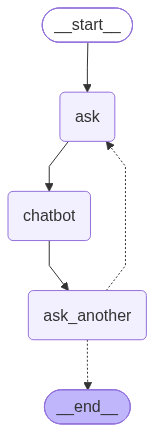

In [31]:
graph_complied = graph.compile()

graph_complied

In [32]:
graph_complied.invoke(MessagesState(messages=[]))


-------> Entering the ask state
What is your Question ?

--------------> Entering Chatbot:
================================== Ai Message ==================================


<think>
Here's a thinking process:

1.  **Identify the User's Question**: The user is asking "Who is the PM of India?"
2.  **Identify Key Entity**: "PM of India" refers to the Prime Minister of India.
3.  **Determine Current Information**: As of my last update (2024), the Prime Minister of India is Narendra Modi. He has been in office since May 2014 and was re-elected for a third term in June 2024.
4.  **Verify Accuracy**: I need to confirm that this information is still current. Since my knowledge cutoff is 2024, and Narendra Modi's third term began in June 2024, this is accurate. I should also note that political positions can change, so it's good practice to mention the timeframe or suggest verifying with up-to-date sources if needed.
5.  **Formulate Response**: Keep it clear, direct, and accurate. State the na

{'messages': [AIMessage(content='What is your Question ?', additional_kwargs={}, response_metadata={}, id='d9ce4234-88f0-4954-98e0-eb34a40f18e4', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Who is the PM of India', additional_kwargs={}, response_metadata={}, id='40047dd0-74cf-4b6a-9952-8fd766921df9'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Identify the User\'s Question**: The user is asking "Who is the PM of India?"\n2.  **Identify Key Entity**: "PM of India" refers to the Prime Minister of India.\n3.  **Determine Current Information**: As of my last update (2024), the Prime Minister of India is Narendra Modi. He has been in office since May 2014 and was re-elected for a third term in June 2024.\n4.  **Verify Accuracy**: I need to confirm that this information is still current. Since my knowledge cutoff is 2024, and Narendra Modi\'s third term began in June 2024, this is accurate. I should also note that political positions can change, s